1. Imports

In [4]:
# ============================================================
# IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

print("All libraries imported.")

All libraries imported.


2. Load CSV

In [5]:
# ============================================================
# LOAD DATA
# ============================================================

DATA_PATH = Path(
    "../data/processed/cicids_required_features.csv"
)

MODEL_DIR = Path(
    "../models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

print(
    "Dataset shape:",
    df.shape
)

display(df.head())

Dataset shape: (2827876, 19)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,SYN Flag Count,ACK Flag Count,RST Flag Count,Average Packet Size,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Label
0,54865,3,2,0,12,0,4.000000e+06,666666.66670,666666.666700,0.000000,6,6,6.0,0.0,0,0,1,9.0,BENIGN
1,55054,109,1,1,6,6,1.100917e+05,18348.62385,9174.311927,9174.311927,6,6,6.0,0.0,0,0,1,9.0,BENIGN
2,55055,52,1,1,6,6,2.307692e+05,38461.53846,19230.769230,19230.769230,6,6,6.0,0.0,0,0,1,9.0,BENIGN
3,46236,34,1,1,6,6,3.529412e+05,58823.52941,29411.764710,29411.764710,6,6,6.0,0.0,0,0,1,9.0,BENIGN
4,54863,3,2,0,12,0,4.000000e+06,666666.66670,666666.666700,0.000000,6,6,6.0,0.0,0,0,1,9.0,BENIGN


3. Clean column names

In [6]:
# ============================================================
# CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .astype(str)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'SYN Flag Count', 'ACK Flag Count', 'RST Flag Count', 'Average Packet Size', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Label']


4. Define features

In [7]:
# ============================================================
# FEATURES
# ============================================================

FEATURES = [
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packets/s",
    "Bwd Packets/s",
    "SYN Flag Count",
    "ACK Flag Count",
    "RST Flag Count",
    "Average Packet Size",
    "Min Packet Length",
    "Max Packet Length",
    "Packet Length Mean",
    "Packet Length Std"
]

missing = [
    f for f in FEATURES
    if f not in df.columns
]

if missing:
    raise ValueError(
        f"Missing features: {missing}"
    )

print(
    f"{len(FEATURES)} features available."
)

18 features available.


5. Create binary target

In [8]:
# ============================================================
# BINARY TARGET
# ============================================================

df["Label"] = (
    df["Label"]
    .astype(str)
    .str.strip()
)

df["target"] = np.where(
    df["Label"].str.upper() == "BENIGN",
    0,
    1
).astype("int8")

df["binary_label"] = np.where(
    df["target"] == 0,
    "NOT ATTACK",
    "ATTACK"
)

display(
    df["binary_label"].value_counts()
)

binary_label
NOT ATTACK    2271320
ATTACK         556556
Name: count, dtype: int64

6. Clean numeric data

In [9]:
# ============================================================
# NUMERIC CLEANING
# ============================================================

for column in FEATURES:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Infinite → NaN
df[FEATURES] = df[FEATURES].replace(
    [np.inf, -np.inf],
    np.nan
)

print(
    "Missing values before cleaning:",
    df[FEATURES].isna().sum().sum()
)

# Remove invalid rows
before = len(df)

df = df.dropna(
    subset=FEATURES + ["target"]
).copy()

after = len(df)

print(
    f"Rows removed: {before - after:,}"
)
print(
    f"Rows remaining: {after:,}"
)

Missing values before cleaning: 0
Rows removed: 0
Rows remaining: 2,827,876


7. Remove exact duplicates

In [10]:
# ============================================================
# REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicates:,}"
)

print(
    f"Duplicate percentage: "
    f"{duplicates / len(df) * 100:.2f}%"
)

df = df.drop_duplicates(
    keep="first"
).reset_index(
    drop=True
)

print(
    "Shape after duplicate removal:",
    df.shape
)

Duplicate rows: 548,621
Duplicate percentage: 19.40%
Shape after duplicate removal: (2279255, 21)


8. X and y

In [11]:
# ============================================================
# X / y
# ============================================================

X = df[FEATURES].copy()

y = df["target"].copy()

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (2279255, 18)
y shape: (2279255,)


9. Train/test split

In [12]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y
)

print(
    "Training:",
    X_train.shape
)

print(
    "Testing:",
    X_test.shape
)

Training: (1823404, 18)
Testing: (455851, 18)


10. Class imbalance

In [13]:
# ============================================================
# CLASS WEIGHT
# ============================================================

negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count /
    positive_count
)

print(
    f"NOT ATTACK: {negative_count:,}"
)

print(
    f"ATTACK: {positive_count:,}"
)

print(
    f"scale_pos_weight: "
    f"{scale_pos_weight:.4f}"
)

NOT ATTACK: 1,490,411
ATTACK: 332,993
scale_pos_weight: 4.4758


11. KNN / Logistic sample

In [15]:
# ============================================================
# REPRESENTATIVE SAMPLE
# FOR LOGISTIC + KNN
# ============================================================

LR_KNN_SIZE = min(
    100_000,
    len(X_train)
)

X_lrknn, _, y_lrknn, _ = train_test_split(

    X_train,

    y_train,

    train_size=LR_KNN_SIZE,

    random_state=RANDOM_STATE,

    stratify=y_train
)

print(
    "Logistic/KNN training size:",
    X_lrknn.shape
)

display(
    y_lrknn.value_counts(
        normalize=True
    )
)

Logistic/KNN training size: (100000, 18)


target
0    0.81738
1    0.18262
Name: proportion, dtype: float64

12. Define all four models

Logistic Regression pipeline

In [16]:
# ============================================================
# LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_pipeline = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

KNN pipeline

In [17]:
# ============================================================
# KNN PIPELINE
# ============================================================

knn_pipeline = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            n_jobs=-1
        )
    )
])

Random Forest

In [18]:
# ============================================================
# RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(

    n_estimators=200,

    class_weight="balanced",

    random_state=RANDOM_STATE,

    n_jobs=-1
)

XGBoost

In [19]:
# ============================================================
# XGBOOST
# ============================================================

xgb_model = XGBClassifier(

    objective="binary:logistic",

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_weight=1,

    gamma=0,

    reg_alpha=0,

    reg_lambda=1,

    scale_pos_weight=scale_pos_weight,

    eval_metric="logloss",

    random_state=RANDOM_STATE,

    n_jobs=-1,

    tree_method="hist"
)

13. Evaluation function

In [20]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    start = time.time()

    # Prediction
    y_pred = model.predict(
        X_test
    )

    # Probability
    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    inference_time = (
        time.time() - start
    )

    results = {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),

        "Precision":
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_test,
                y_prob
            ),

        "PR-AUC":
            average_precision_score(
                y_test,
                y_prob
            ),

        "Inference Time (sec)":
            inference_time
    }

    print(
        "\n" + "=" * 70
    )

    print(
        model_name
    )

    print(
        "=" * 70
    )

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "NOT ATTACK",
                "ATTACK"
            ],
            zero_division=0
        )
    )

    return (
        results,
        y_pred,
        y_prob
    )

14. Train Logistic Regression

In [21]:
# ============================================================
# TRAIN 1 — LOGISTIC REGRESSION
# ============================================================

print(
    "Training Logistic Regression..."
)

start = time.time()

logistic_pipeline.fit(
    X_lrknn,
    y_lrknn
)

print(
    f"Training time: "
    f"{time.time() - start:.2f} sec"
)

Training Logistic Regression...
Training time: 0.61 sec


In [22]:
logistic_results, logistic_pred, logistic_prob = (
    evaluate_model(
        logistic_pipeline,
        X_test,
        y_test,
        "Logistic Regression"
    )
)


Logistic Regression
              precision    recall  f1-score   support

  NOT ATTACK       0.99      0.81      0.89    372603
      ATTACK       0.53      0.95      0.68     83248

    accuracy                           0.84    455851
   macro avg       0.76      0.88      0.79    455851
weighted avg       0.90      0.84      0.85    455851



15. Train KNN

In [23]:
# ============================================================
# TRAIN 2 — KNN
# ============================================================

print(
    "Training KNN..."
)

start = time.time()

knn_pipeline.fit(
    X_lrknn,
    y_lrknn
)

print(
    f"Training time: "
    f"{time.time() - start:.2f} sec"
)

Training KNN...
Training time: 0.05 sec


In [24]:
knn_results, knn_pred, knn_prob = (
    evaluate_model(
        knn_pipeline,
        X_test,
        y_test,
        "KNN"
    )
)


KNN
              precision    recall  f1-score   support

  NOT ATTACK       0.99      0.99      0.99    372603
      ATTACK       0.96      0.96      0.96     83248

    accuracy                           0.99    455851
   macro avg       0.97      0.98      0.98    455851
weighted avg       0.99      0.99      0.99    455851



16. Train Random Forest

In [25]:
# ============================================================
# TRAIN 3 — RANDOM FOREST
# ============================================================

print(
    "Training Random Forest..."
)

start = time.time()

rf_model.fit(
    X_train,
    y_train
)

print(
    f"Training time: "
    f"{time.time() - start:.2f} sec"
)

Training Random Forest...
Training time: 94.32 sec


In [26]:
rf_results, rf_pred, rf_prob = (
    evaluate_model(
        rf_model,
        X_test,
        y_test,
        "Random Forest"
    )
)


Random Forest
              precision    recall  f1-score   support

  NOT ATTACK       1.00      1.00      1.00    372603
      ATTACK       0.98      0.99      0.99     83248

    accuracy                           1.00    455851
   macro avg       0.99      0.99      0.99    455851
weighted avg       1.00      1.00      1.00    455851



17. Train XGBoost

In [27]:
# ============================================================
# TRAIN 4 — XGBOOST
# ============================================================

print(
    "Training XGBoost..."
)

start = time.time()

xgb_model.fit(
    X_train,
    y_train
)

print(
    f"Training time: "
    f"{time.time() - start:.2f} sec"
)

Training XGBoost...
Training time: 13.23 sec


In [28]:
xgb_results, xgb_pred, xgb_prob = (
    evaluate_model(
        xgb_model,
        X_test,
        y_test,
        "XGBoost"
    )
)


XGBoost
              precision    recall  f1-score   support

  NOT ATTACK       1.00      1.00      1.00    372603
      ATTACK       0.99      0.99      0.99     83248

    accuracy                           1.00    455851
   macro avg       0.99      0.99      0.99    455851
weighted avg       1.00      1.00      1.00    455851



18. Combine results

In [29]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame([

    logistic_results,

    knn_results,

    rf_results,

    xgb_results

])

results_df = results_df.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({

        "Accuracy":
            "{:.4f}",

        "Precision":
            "{:.4f}",

        "Recall":
            "{:.4f}",

        "F1":
            "{:.4f}",

        "ROC-AUC":
            "{:.4f}",

        "PR-AUC":
            "{:.4f}",

        "Inference Time (sec)":
            "{:.2f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Inference Time (sec)
0,XGBoost,0.9964,0.9880,0.9924,0.9902,0.9999,0.9994,0.42
1,Random Forest,0.9957,0.9847,0.9917,0.9882,0.9987,0.9953,1.36
2,KNN,0.9855,0.9566,0.9642,0.9604,0.9941,0.9810,48.79
3,Logistic Regression,0.8390,0.5333,0.9478,0.6825,0.9403,0.8257,0.15


19. Model comparison chart

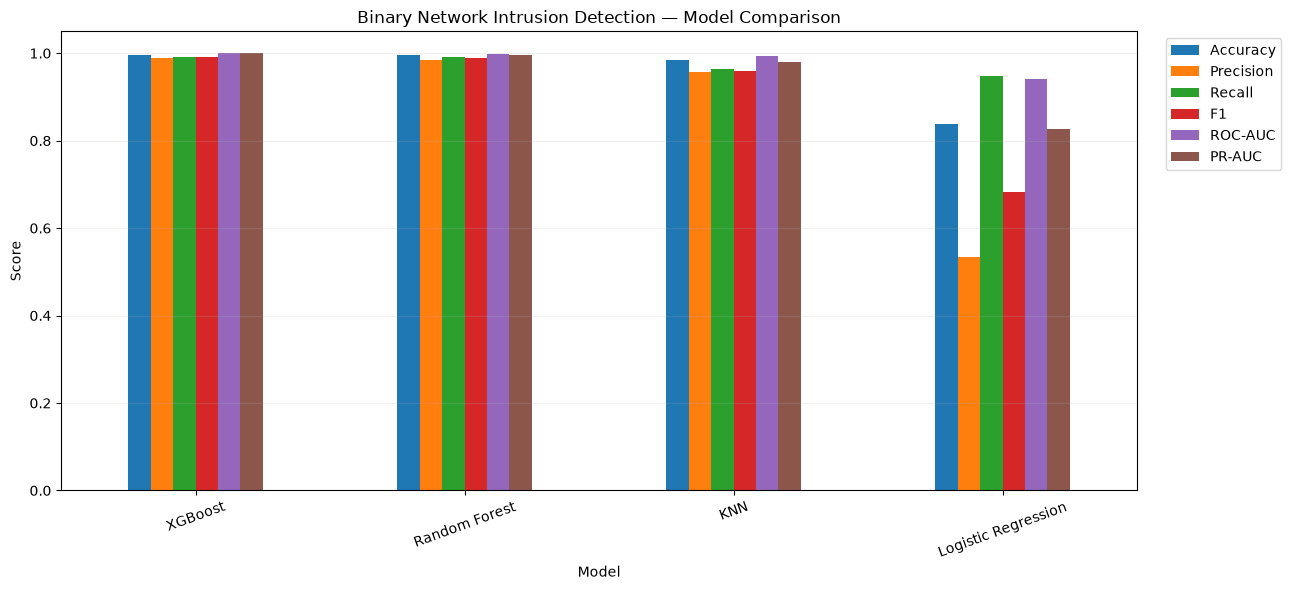

In [30]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

plot_data = results_df.set_index(
    "Model"
)[metrics]

ax = plot_data.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title(
    "Binary Network Intrusion Detection — Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

20. Confusion matrices for all four

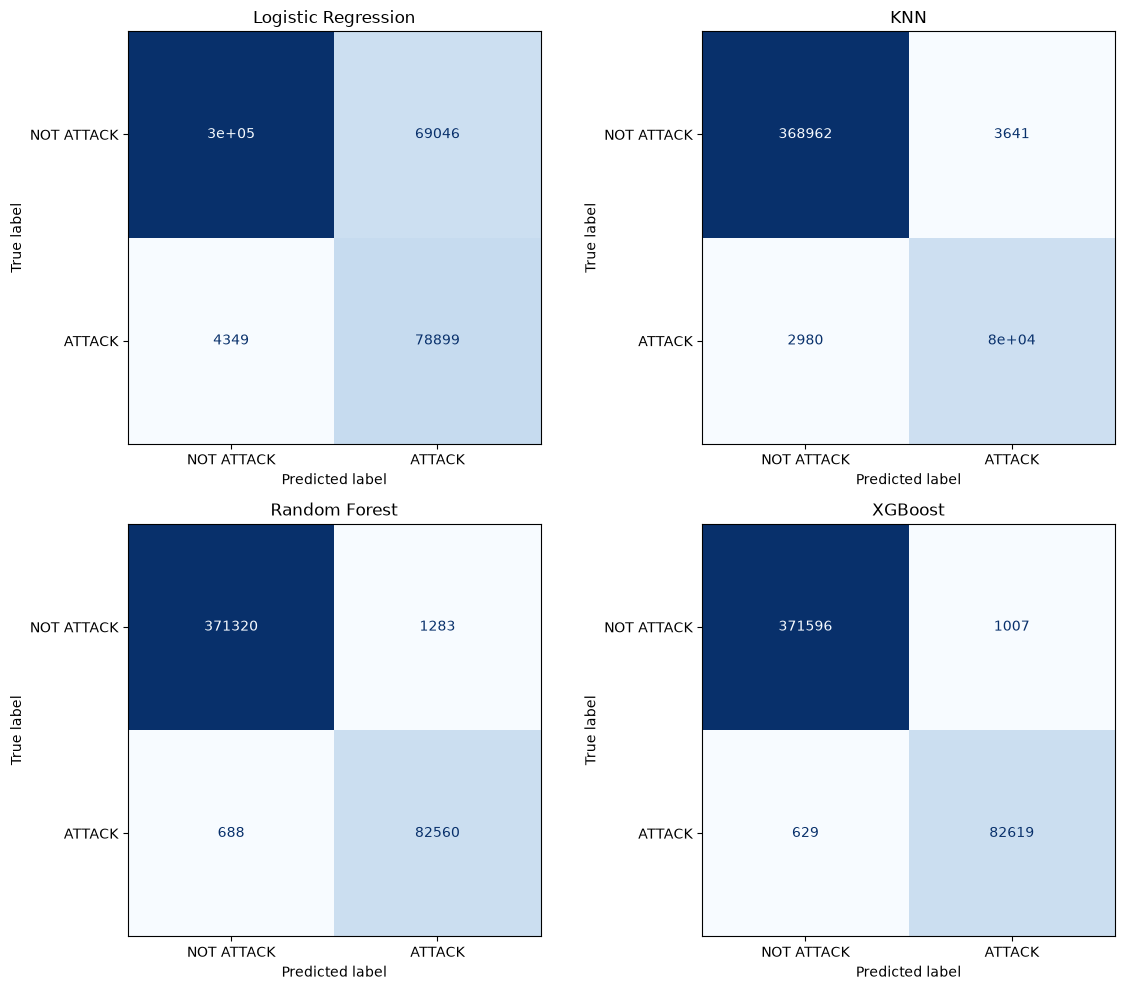

In [31]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

all_predictions = {

    "Logistic Regression":
        logistic_pred,

    "KNN":
        knn_pred,

    "Random Forest":
        rf_pred,

    "XGBoost":
        xgb_pred
}


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)


for ax, (name, pred) in zip(
    axes.ravel(),
    all_predictions.items()
):

    cm = confusion_matrix(
        y_test,
        pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "NOT ATTACK",
            "ATTACK"
        ]
    )

    disp.plot(
        ax=ax,
        colorbar=False, cmap="Blues"
    )

    ax.set_title(
        name
    )


plt.tight_layout()

plt.show()

21. ROC curves for all models

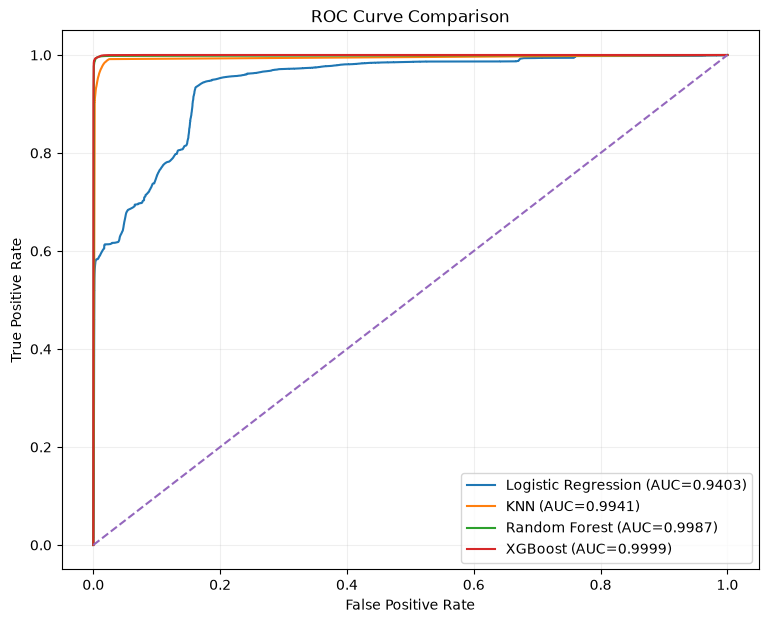

In [32]:
# ============================================================
# ROC CURVES
# ============================================================

all_probabilities = {

    "Logistic Regression":
        logistic_prob,

    "KNN":
        knn_prob,

    "Random Forest":
        rf_prob,

    "XGBoost":
        xgb_prob
}


plt.figure(
    figsize=(9, 7)
)


for name, prob in (
    all_probabilities.items()
):

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    auc_score = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{name} "
            f"(AUC={auc_score:.4f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

22. Precision-Recall curves

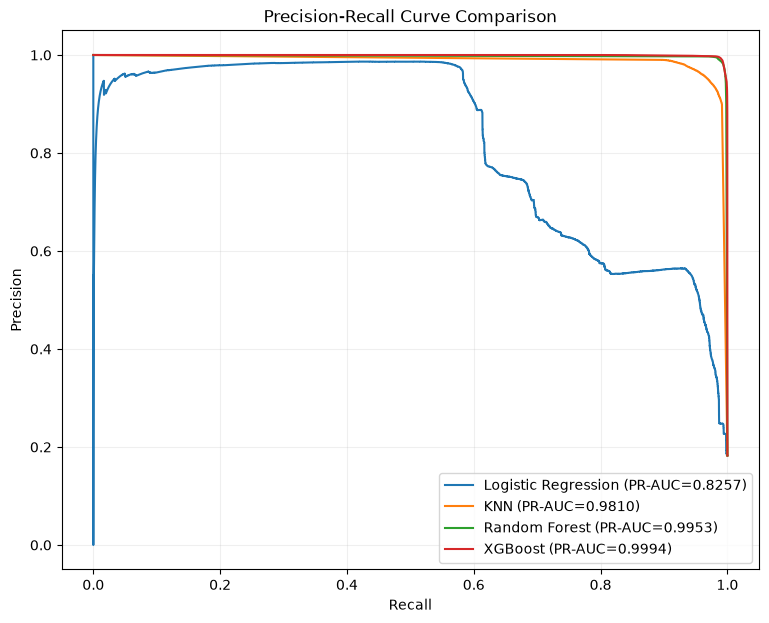

In [33]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(9, 7)
)


for name, prob in (
    all_probabilities.items()
):

    precision, recall, _ = (
        precision_recall_curve(
            y_test,
            prob
        )
    )

    pr_auc = (
        average_precision_score(
            y_test,
            prob
        )
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{name} "
            f"(PR-AUC={pr_auc:.4f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

23. Select the best model

In [34]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

best_row = (
    results_df
    .iloc[0]
)

best_model_name = (
    best_row["Model"]
)

print(
    "BEST MODEL"
)

print(
    "=" * 50
)

print(
    f"Model    : {best_model_name}"
)

print(
    f"Accuracy : {best_row['Accuracy']:.4f}"
)

print(
    f"Precision: {best_row['Precision']:.4f}"
)

print(
    f"Recall   : {best_row['Recall']:.4f}"
)

print(
    f"F1       : {best_row['F1']:.4f}"
)

print(
    f"ROC-AUC  : {best_row['ROC-AUC']:.4f}"
)

print(
    f"PR-AUC   : {best_row['PR-AUC']:.4f}"
)

BEST MODEL
Model    : XGBoost
Accuracy : 0.9964
Precision: 0.9880
Recall   : 0.9924
F1       : 0.9902
ROC-AUC  : 0.9999
PR-AUC   : 0.9994


24. Create model dictionary

In [35]:
# ============================================================
# MODEL DICTIONARY
# ============================================================

trained_models = {

    "Logistic Regression":
        logistic_pipeline,

    "KNN":
        knn_pipeline,

    "Random Forest":
        rf_model,

    "XGBoost":
        xgb_model
}


best_model = trained_models[
    best_model_name
]

25. Find optimal threshold for the best model

In [36]:
# ============================================================
# THRESHOLD OPTIMIZATION
# ============================================================

best_prob = all_probabilities[
    best_model_name
]

threshold_values = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []


for threshold in threshold_values:

    threshold_pred = (
        best_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold":
            threshold,

        "Precision":
            precision_score(
                y_test,
                threshold_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                threshold_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                threshold_pred,
                zero_division=0
            )
    })


threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df
)

,Threshold,Precision,Recall,F1
0,0.10,0.921567,0.999568,0.958984
1,0.15,0.936963,0.999147,0.967056
2,0.20,0.943602,0.998871,0.970450
3,0.25,0.946976,0.998643,0.972123
4,0.30,0.949426,0.998318,0.973258
5,0.35,0.980402,0.993910,0.987110
6,0.40,0.984697,0.993225,0.988943
7,0.45,0.985994,0.992805,0.989388
8,0.50,0.987958,0.992444,0.990196
9,0.55,0.988394,0.992336,0.990361


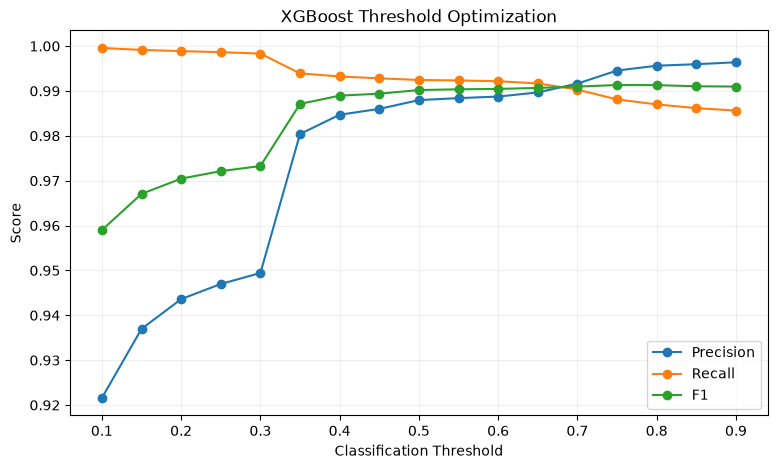

In [37]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    f"{best_model_name} Threshold Optimization"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

26. Best threshold

In [38]:
# ============================================================
# BEST THRESHOLD
# ============================================================

best_threshold_row = (
    threshold_df
    .loc[
        threshold_df["F1"].idxmax()
    ]
)

BEST_THRESHOLD = float(
    best_threshold_row["Threshold"]
)

print(
    f"Best threshold: "
    f"{BEST_THRESHOLD:.2f}"
)

print(
    f"Precision: "
    f"{best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_threshold_row['Recall']:.4f}"
)

print(
    f"F1: "
    f"{best_threshold_row['F1']:.4f}"
)

Best threshold: 0.75
Precision: 0.9945
Recall: 0.9881
F1: 0.9913


27. Final confusion matrix with optimized threshold

              precision    recall  f1-score   support

  NOT ATTACK       1.00      1.00      1.00    372603
      ATTACK       0.99      0.99      0.99     83248

    accuracy                           1.00    455851
   macro avg       1.00      0.99      0.99    455851
weighted avg       1.00      1.00      1.00    455851



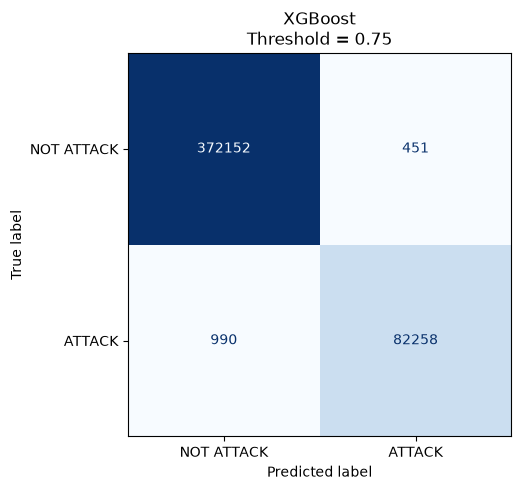

In [39]:
# ============================================================
# FINAL OPTIMIZED CONFUSION MATRIX
# ============================================================

final_pred = (
    best_prob >= BEST_THRESHOLD
).astype(int)

print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "NOT ATTACK",
            "ATTACK"
        ],
        zero_division=0
    )
)


cm = confusion_matrix(
    y_test,
    final_pred
)


fig, ax = plt.subplots(
    figsize=(6, 5)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "NOT ATTACK",
        "ATTACK"
    ]
)

disp.plot(
    ax=ax, colorbar=False, cmap="Blues"
)

ax.set_title(
    f"{best_model_name}\n"
    f"Threshold = {BEST_THRESHOLD:.2f}"
)

plt.tight_layout()

plt.show()

28. XGBoost feature importance

,importance
Packet Length Std,0.286827
Average Packet Size,0.285534
ACK Flag Count,0.137811
RST Flag Count,0.053719
Flow Bytes/s,0.042834
Destination Port,0.040197
Total Length of Bwd Packets,0.029387
Packet Length Mean,0.019735
Total Backward Packets,0.018472
Bwd Packets/s,0.016008


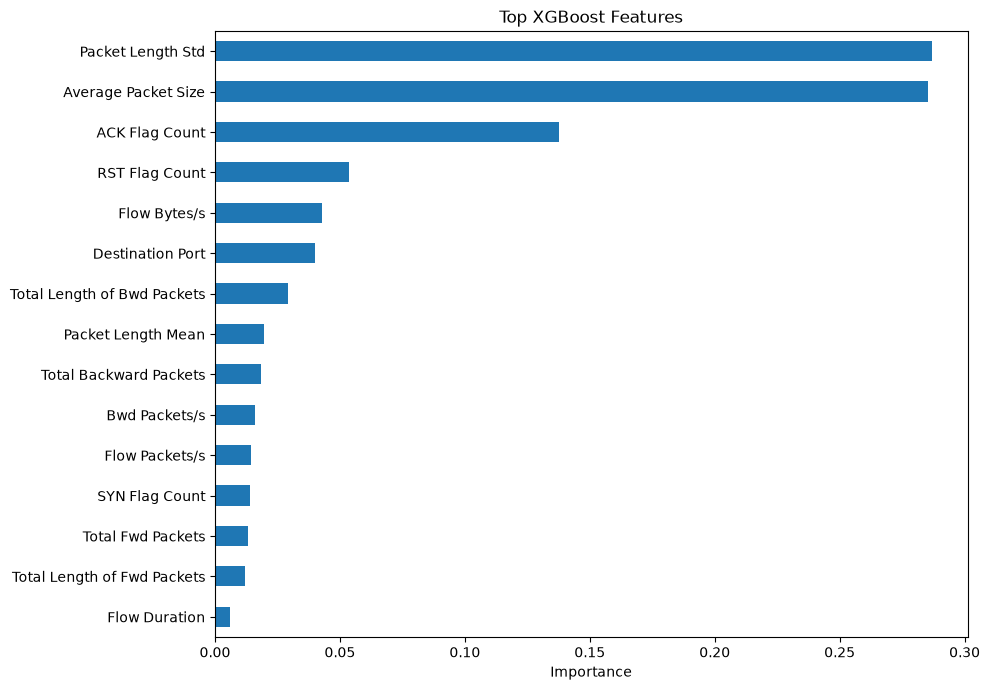

In [40]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

if best_model_name == "XGBoost":

    importance = pd.Series(

        xgb_model.feature_importances_,

        index=FEATURES

    ).sort_values(
        ascending=False
    )

    display(
        importance.to_frame(
            "importance"
        )
    )


    plt.figure(
        figsize=(10, 7)
    )


    importance.head(15).sort_values().plot(
        kind="barh"
    )


    plt.xlabel(
        "Importance"
    )

    plt.title(
        "Top XGBoost Features"
    )

    plt.tight_layout()

    plt.show()

else:

    print(
        "XGBoost was not selected as the best model."
    )

29. Save all four trained pipelines/models

In [48]:
# ============================================================
# SAVE ALL FOUR MODELS
# ============================================================

joblib.dump(
    logistic_pipeline,
    MODEL_DIR / "logistic_regression_pipeline.pkl"
)

joblib.dump(
    knn_pipeline,
    MODEL_DIR / "knn_pipeline.pkl"
)

joblib.dump(
    rf_model,
    MODEL_DIR / "random_forest.pkl"
)

joblib.dump(
    xgb_model,
    MODEL_DIR / "xgboost.pkl"
)

print(
    "All four models saved."
)

All four models saved.


30. Save the best model

In [49]:
# ============================================================
# SAVE BEST MODEL
# ============================================================

joblib.dump(
    best_model,
    MODEL_DIR / "best_model.pkl"
)

joblib.dump(
    FEATURES,
    MODEL_DIR / "features.pkl"
)

metadata = {

    "best_model":
        best_model_name,

    "selection_metric":
        "PR-AUC",

    "threshold":
        BEST_THRESHOLD,

    "target_mapping":
        {
            "0": "NOT ATTACK",
            "1": "ATTACK"
        },

    "features":
        FEATURES
}


with open(
    MODEL_DIR / "model_metadata.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


print(
    "Best model saved:"
)

print(
    MODEL_DIR / "best_model.pkl"
)

print(
    MODEL_DIR / "features.pkl"
)

print(
    MODEL_DIR / "model_metadata.json"
)

Best model saved:
..\models\best_model.pkl
..\models\features.pkl
..\models\model_metadata.json


31. Test the saved model

In [50]:
# ============================================================
# TEST SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    MODEL_DIR / "best_model.pkl"
)

loaded_features = joblib.load(
    MODEL_DIR / "features.pkl"
)


print(
    "Loaded model:",
    type(loaded_model)
)

print(
    "Features:",
    len(loaded_features)
)

Loaded model: <class 'xgboost.sklearn.XGBClassifier'>
Features: 18


In [51]:
# Test predictions

test_sample = X_test.iloc[:10]

test_predictions = (
    loaded_model
    .predict(test_sample)
)

test_probabilities = (
    loaded_model
    .predict_proba(test_sample)[:, 1]
)

test_output = pd.DataFrame({

    "Actual":
        y_test.iloc[:10].values,

    "Prediction":
        test_predictions,

    "Attack Probability":
        test_probabilities

})

test_output["Actual"] = (
    test_output["Actual"]
    .map({
        0: "NOT ATTACK",
        1: "ATTACK"
    })
)

test_output["Prediction"] = (
    test_output["Prediction"]
    .map({
        0: "NOT ATTACK",
        1: "ATTACK"
    })
)

display(
    test_output
)

,Actual,Prediction,Attack Probability
0,ATTACK,ATTACK,0.964277
1,NOT ATTACK,NOT ATTACK,0.000050
2,NOT ATTACK,NOT ATTACK,0.000042
3,NOT ATTACK,NOT ATTACK,0.003286
4,ATTACK,ATTACK,0.999979
5,NOT ATTACK,NOT ATTACK,0.000033
6,NOT ATTACK,NOT ATTACK,0.000086
7,NOT ATTACK,NOT ATTACK,0.000744
8,NOT ATTACK,NOT ATTACK,0.000034
9,NOT ATTACK,NOT ATTACK,0.000023
